In [ ]:
import matplotlib.pyplot as plt
from ISUILCC_LFPGr_Data import *

c:\Users\pgasper\AppData\Local\anaconda3\envs\cannele\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = Dataset_ISUILCC_LFPGr(is_short=True)  # Load only a subset of the cells for testing purposes

Loading data for cell 2 of 65...
Loading data for cell 6 of 65...
Loading data for cell 64 of 65...
Loading data for cell 65 of 65...


In [3]:
# If you just want all the extracts and metadata values for all cells from a data set, use `get_dataset_summary_table`:
data.get_dataset_summary_table()

,charge_cv_time,discharge_dVdQ_90SOC,log_energy_inefficiency,DeltaV_40SOC,DeltaV_93SOC,discharge_dVdQ_25SOC,charge_capacity,discharge_dVdQ_70SOC,discharge_QV_3200mV,discharge_dVdQ_82SOC,...,repeat_num,cell_id,Cell ID,GroupNumber,Group Channel,C_chg,C_dis,DoD,days_to_80percent_C/3_capacity,log_days_to_80percent_C/3_capacity
0,938.4,-4.279520,0.662494,0.160681,0.188047,-42.631838,1.209499,-3.472269,0.932347,-0.185352,...,1,cell_2,2,1,1,2.0,1.5,0.6,141.818391,4.954547
1,554.5,-4.482891,0.664590,0.156134,0.174074,-60.454180,1.200677,-3.573002,0.932427,-0.209377,...,2,cell_2,2,1,1,2.0,1.5,0.6,141.818391,4.954547
2,299.5,-4.711282,0.665999,0.155447,0.166330,-64.875531,1.187617,-3.565287,0.917761,-0.218185,...,3,cell_2,2,1,1,2.0,1.5,0.6,141.818391,4.954547
3,286.7,-4.729008,0.666437,0.155022,0.161539,-74.191040,1.182256,-3.420240,0.912566,-0.227937,...,4,cell_2,2,1,1,2.0,1.5,0.6,141.818391,4.954547
4,271.4,-4.715436,0.666575,0.155578,0.156787,-71.084103,1.177004,-3.618039,0.908160,-0.220129,...,5,cell_2,2,1,1,2.0,1.5,0.6,141.818391,4.954547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,540.2,-5.433710,0.658153,0.185945,0.308007,-41.840521,1.056514,-3.178305,0.793199,-0.172508,...,26,cell_65,5,1,4,2.0,1.5,0.6,121.355382,4.798723
131,579.7,-5.163671,0.657536,0.187608,0.319050,-42.456016,1.041680,-3.146777,0.776484,-0.171429,...,27,cell_65,5,1,4,2.0,1.5,0.6,121.355382,4.798723
132,678.8,-4.818320,0.656385,0.194530,0.301824,-41.893911,1.016667,-3.041645,0.748470,-0.167404,...,28,cell_65,5,1,4,2.0,1.5,0.6,121.355382,4.798723
133,753.6,-5.175088,0.655155,0.199463,0.335077,-42.904829,0.982976,-2.946511,0.713497,-0.167439,...,29,cell_65,5,1,4,2.0,1.5,0.6,121.355382,4.798723


All matrix extraction methods return two outputs:
- a `list` of cell_ids for each row of any x and y pair(s)
- `tuple`(s) of x-y pair(s), where both `x` and `y` are `pd.DataFrame`s

For each given type of model, the result may be a single list of cell_ids and a single (x,y) tuple, or a list of lists of cell_ids and a list of (x,y) tuples:
- `get_failure_matrices`: failure prediction models use data from measurement N to predict a single target (presumed to be some information about cell failure, like time to failure or capacity at the final measurement). So for each measurement 1:N in a data set, there is a separate model, with a potentially variable number of cells depending on which cells have valid data at a given measurement number (they may fail at different times, for instance).
    - the output is list of cell_id lists, and a list of (x,y) tuples for each measurement number
- `get_rul_matrices`: remaining useful life (RUL) models use data from measurement N to predict the remaining measurements until failure (or some other user-defined 'tracking' variable). Unlike the failure prediction model, this means that all data from all measurements of every cell can simply be stacked together, though the relationships the model will need to learn may be more complicated than a failure prediction model.
    - the output is list of cell_ids for each row in x and y, and the single (x,y) tuple
- `get_lookahead_matrices`: look-ahead prediction models use data from measurement N to predict the target at some measurement N+t. So for each measurement 1:N in a data set, and for each number of 'look-aheads' t, there is a separate model, with a potentially variable number of cells depending on which cells have valid data at a given measurement number and valid data at the future measurement N+t.
    - the output is a list of cell_id lsits, and a list of (x,y) tuples for each measurement number
- `get_autoregressive_matrices`: autoregressive models use data from any measurement to predict the target at some future measurement, i.e., always predicting the target at some future time regardless of where the current measurement is in the testing sequence. The input data can be just the data from the current measurement, or there can be additional data from 'lags', i.e., data from past as well as current measurements. Often, both the lagged input data as well as the targets are differences from the current values for autoregressive models (this is an optional input; best practices vary based on the specific prediction problem). Unlike the 'look-ahead' prediction problem, this means that all data from all measurements (well, all expect the first 'lags' measurements of each cell) can simply be stacked together, though the relationships the model will need to learn may be more complicated than a failure prediction model.
    - the output is a list of cell_ids for each row in x and y, and a single (x,y) tuple
- `get_trajectory_matrices`: trajectory models simply predict the trajectory of a single target from a single chronological variable, like time, cycle count, or measurement number; basically, just predicting the change of a single variable over time, like `y = a*time + b`. Each trajectory of each cell is unique.
    - the output is a list of cell_ids for each (x,y) tuple, and list of (x,y) tuples, one for each cell

There are several parameters related to data processing that are common across many of the matrix extraction methods:
- `target_var_name`: the name of the variable to use as target data, i.e., to fill the y-matrices. This cannot automatically handle removing other variables that may cause data leakage, so carefully filter your data set for any possible data leakage; for instance, your target may be the log of cycle life, but the cycle life feature is still in the X matrices.
- `nan_filter_method`: either 'drop_columns', 'drop_rows', or 'fill_zero' -  there's really no general treatment for NaNs for all cases, so we give options.
- `n_skip_measurements`: skips 'n' measurements from the beginning of the measurement sequence for any cell when creating matrices. Useful for cases where the first cycle (or first few cycles) from any cell have features with NaNs, like 'log_delta' features (difference of some feature between measurement N and meausrement 0 is 0 at measurement 0, log(0) is -Inf or NaN)
- `force_consistent_vars`: for functions that return many independent sets of matrices (`get_failure_matrices`, `get_lookahead_matrices`), it can be inconvenient sometimes if each X matrix does not have exactly the same variables as the others. This can happen sometimes due to missing data from specific measurement or features that are NaN for a specific cell... or other reasons, data is messy! This enforces that every X matrix has exactly the same feature columns as all others.

In [4]:
cell_ids, xy_pairs = data.get_failure_matrices()

In [5]:
len(cell_ids), len(xy_pairs)

(35, 35)

In [6]:
cell_ids

[['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2'

In [7]:
# x-y pairs are always tuples (x,y), where the 0th element is x and the 1st element is y
xy_pairs[10][0]

,charge_cv_time,discharge_dVdQ_90SOC,discharge_log_abs_delta_dVdQ_80SOC,log_abs_mean_DeltaV_SOC,discharge_log_abs_delta_dQdV_3160mV,discharge_delta_dVdQ_90SOC,delta_DeltaV_SOC_40SOC_1C,DeltaV_93SOC,delta_DeltaV_SOC_60SOC_1C,cycle,...,log_relative_DeltaV_SOC_60SOC_1C,discharge_delta_dQdV_3262mV,discharge_dQdV_3305mV,discharge_delta_dQdV_3305mV,discharge_QV_3350mV,log_relative_DeltaV_SOC_3SOC_1C,discharge_relative_QV_3280mV,discharge_QV_3280mV,relative_DeltaV_SOC_40SOC_1C,discharge_log_abs_delta_QV_3200mV
0,292.7,-4.823175,-5.145983,-3.428319,0.798172,-0.543655,-0.007117,0.135589,-0.011691,1110.0,...,-0.079018,-14.413733,-12.784939,7.333263,0.011458,-0.571983,0.859020,0.294044,0.955705,-3.070117
1,283.9,-4.414491,-4.413867,-3.463058,0.732422,-0.150927,-0.003389,0.123215,-0.012608,1112.0,...,-0.085970,-10.719204,-12.901639,5.760346,0.011619,-0.582450,0.861990,0.294870,0.978790,-3.083723
2,309.0,-4.948823,-6.237795,-4.419058,0.347393,-0.732536,0.002805,0.179746,-0.008406,978.0,...,-0.056484,-12.895615,-15.456385,5.251365,0.011316,-0.176818,0.895496,0.299682,1.017582,-3.352001
3,314.7,-5.020531,-3.750074,-5.435248,0.353126,-1.022588,0.005479,0.188985,-0.005405,975.0,...,-0.036299,-6.504831,-13.729194,5.043668,0.011811,-0.098713,0.895436,0.307673,1.034791,-3.250442


In [8]:
xy_pairs[10][1]

,log_days_to_80percent_C/3_capacity
0,4.954547
1,4.982696
2,4.922670
3,4.798723


In [9]:
for (x, y) in xy_pairs:
    print(x.shape, y.shape)

(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(3, 180) (3, 1)
(3, 180) (3, 1)
(3, 180) (3, 1)
(3, 180) (3, 1)
(2, 180) (2, 1)
(1, 180) (1, 1)


In [10]:
# example where we keep cycle 0 data and force consisntent variables
# cycle 0 has several feature columns that are NaN so we lose columns in x.
cell_ids, xy_pairs = data.get_failure_matrices(n_skip_measurements=0)
for (x, y) in xy_pairs:
    print(x.shape, y.shape)

(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(4, 141) (4, 1)
(3, 141) (3, 1)
(3, 141) (3, 1)
(3, 141) (3, 1)
(3, 141) (3, 1)
(2, 141) (2, 1)
(1, 141) (1, 1)


In [11]:
# example where we keep cycle 0 data and do not force consisntent variables
# cycle 0 has several feature columns that are NaN so we lose columns in x.
cell_ids, xy_pairs = data.get_failure_matrices(n_skip_measurements=0, force_consistent_vars=False)
for (x, y) in xy_pairs:
    print(x.shape, y.shape)

(4, 142) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 180) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(4, 182) (4, 1)
(3, 182) (3, 1)
(3, 183) (3, 1)
(3, 183) (3, 1)
(3, 183) (3, 1)
(2, 183) (2, 1)
(1, 183) (1, 1)


In [12]:
cell_ids, (x, y) = data.get_rul_matrices()

In [13]:
len(cell_ids), len(x), len(y)

(127, 127, 127)

In [14]:
cell_ids

['cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',

In [15]:
x

,charge_cv_time,discharge_dVdQ_90SOC,log_energy_inefficiency,DeltaV_40SOC,DeltaV_93SOC,discharge_dVdQ_25SOC,charge_capacity,discharge_dVdQ_70SOC,discharge_QV_3200mV,discharge_dVdQ_82SOC,...,log_abs_mean_Delta_QV_Ah,log_abs_mean_Delta_dQdV_Ah/V,log_abs_mean_Delta_dVdQ_V/Ah,log_abs_mean_DeltaV_SOC,measurement_type,start_time_s,start_time_day,cycle,charge_throughput_Ah,repeat_num
0,554.5,-4.482891,0.664590,0.156134,0.174074,-60.454180,1.200677,-3.573002,0.932427,-0.209377,...,-5.893923,-5.705160,2.129283,-4.447659,RPT,474846.0,5.495903,107.0,-0.001260,2
1,299.5,-4.711282,0.665999,0.155447,0.166330,-64.875531,1.187617,-3.565287,0.917761,-0.218185,...,-4.242665,-4.394886,1.776771,-4.117023,RPT,804569.0,9.312141,202.0,-0.536717,3
2,286.7,-4.729008,0.666437,0.155022,0.161539,-74.191040,1.182256,-3.420240,0.912566,-0.227937,...,-3.983457,-3.953985,1.881441,-3.953105,RPT,1162349.0,13.453113,301.0,-1.721705,4
3,271.4,-4.715436,0.666575,0.155578,0.156787,-71.084103,1.177004,-3.618039,0.908160,-0.220129,...,-3.771773,-3.859778,1.900176,-3.873285,RPT,1507257.0,17.445104,401.0,-2.695637,5
4,252.3,-4.712094,0.667252,0.154262,0.145667,-78.988202,1.172315,-3.485579,0.905666,-0.226888,...,-3.638679,-3.748917,1.986270,-3.688706,RPT,1850636.0,21.419398,501.0,-3.759575,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,537.9,-5.427562,0.658747,0.181557,0.292329,-40.143149,1.066951,-3.194692,0.804089,-0.172020,...,-2.208674,-2.491022,2.216496,-3.386651,RPT,8715672.0,100.875833,2211.0,-15.564158,25
123,540.2,-5.433710,0.658153,0.185945,0.308007,-41.840521,1.056514,-3.178305,0.793199,-0.172508,...,-2.129752,-2.409357,2.165603,-3.291709,RPT,9103247.0,105.361655,2308.0,-16.027977,26
124,579.7,-5.163671,0.657536,0.187608,0.319050,-42.456016,1.041680,-3.146777,0.776484,-0.171429,...,-2.023017,-2.305749,2.155108,-3.177376,RPT,9446481.0,109.334271,2406.0,-16.635481,27
125,678.8,-4.818320,0.656385,0.194530,0.301824,-41.893911,1.016667,-3.041645,0.748470,-0.167404,...,-1.869681,-2.157421,2.165931,-2.992663,RPT,9796448.0,113.384815,2507.0,-17.426418,28


In [16]:
y

0      4.915023
1      4.886630
2      4.854880
3      4.823287
4      4.790811
         ...   
122    3.019427
123    2.772197
124    2.486664
125    2.075756
126    1.383101
Name: log_remaining_days_to_80percent_C/3_capacity, Length: 127, dtype: float64

In [17]:
cell_ids, xy_pairs = data.get_lookahead_matrices(n_skip_measurements=1)

In [18]:
for cell_id, (x, y) in zip(cell_ids, xy_pairs):
    print(len(cell_id), x.shape, y.shape)

4 (4, 180) (4, 34)
4 (4, 180) (4, 33)
4 (4, 180) (4, 32)
4 (4, 180) (4, 31)
4 (4, 180) (4, 30)
4 (4, 180) (4, 29)
4 (4, 180) (4, 28)
4 (4, 180) (4, 27)
4 (4, 180) (4, 26)
4 (4, 180) (4, 25)
4 (4, 180) (4, 24)
4 (4, 180) (4, 23)
4 (4, 180) (4, 22)
4 (4, 180) (4, 21)
4 (4, 180) (4, 20)
4 (4, 180) (4, 19)
4 (4, 180) (4, 18)
4 (4, 180) (4, 17)
4 (4, 180) (4, 16)
4 (4, 180) (4, 15)
4 (4, 180) (4, 14)
4 (4, 180) (4, 13)
4 (4, 180) (4, 12)
4 (4, 180) (4, 11)
4 (4, 180) (4, 10)
4 (4, 180) (4, 9)
4 (4, 180) (4, 8)
4 (4, 180) (4, 7)
3 (3, 180) (3, 6)
3 (3, 180) (3, 5)
3 (3, 180) (3, 4)
3 (3, 180) (3, 3)
2 (2, 180) (2, 2)
1 (1, 180) (1, 1)


In [19]:
len(cell_ids), len(xy_pairs)

(34, 34)

In [20]:
cell_ids

[['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2', 'cell_6', 'cell_64', 'cell_65'],
 ['cell_2'

In [21]:
xy_pairs[0][0]

,charge_cv_time,discharge_log_abs_delta_dVdQ_80SOC,discharge_dVdQ_90SOC,log_abs_mean_DeltaV_SOC,discharge_log_abs_delta_dQdV_3160mV,discharge_delta_dVdQ_90SOC,delta_DeltaV_SOC_40SOC_1C,DeltaV_93SOC,delta_DeltaV_SOC_60SOC_1C,cycle,...,log_relative_DeltaV_SOC_60SOC_1C,discharge_delta_dQdV_3262mV,discharge_dQdV_3305mV,discharge_delta_dQdV_3305mV,discharge_QV_3350mV,log_abs_mean_Delta_dVdQ_V/Ah,discharge_relative_QV_3280mV,discharge_QV_3280mV,relative_DeltaV_SOC_40SOC_1C,discharge_dVdQ_3SOC
0,554.5,-4.200224,-4.482891,-4.447659,-1.549854,-0.203371,-0.004547,0.174074,-0.004190,107.0,...,-0.027610,-5.520843,-16.839805,3.278397,0.009429,2.129283,0.995087,0.340620,0.971702,-64.946672
1,553.3,-4.088554,-4.479038,-4.547649,-2.297174,-0.215473,-0.004194,0.172932,-0.004205,107.0,...,-0.027857,-6.484260,-18.216077,0.445908,0.009392,1.914208,0.994386,0.340160,0.973748,-66.880319
2,536.8,-4.660014,-4.511507,-4.599665,-2.180543,-0.295220,-0.003570,0.169283,-0.004057,95.0,...,-0.026860,-5.288462,-16.085653,4.622097,0.009938,1.917886,0.992332,0.332089,0.977620,-63.138598
3,512.9,-3.866642,-4.450554,-4.889733,-0.659833,-0.452612,-0.002243,0.167623,-0.002782,94.0,...,-0.018523,-3.449211,-18.948246,-0.175384,0.010592,0.888051,1.001896,0.344253,0.985758,-61.572741


In [22]:
xy_pairs[0][1]

,2,3,4,5,6,7,8,9,10,11,...,26,27,28,29,30,31,32,33,34,35
0,0.982586,0.978098,0.973694,0.969892,0.966775,0.963084,0.959808,0.955648,0.951785,0.947724,...,0.871762,0.863786,0.857336,0.847765,0.838113,0.826833,0.816645,0.805372,0.790931,NaN
1,0.982898,0.978384,0.973944,0.970305,0.967255,0.963617,0.960435,0.956386,0.952917,0.948940,...,0.878882,0.871888,0.866615,0.858616,0.850802,0.841297,0.832053,0.821108,0.804799,0.786751
2,0.988594,0.985518,0.982826,0.980208,0.977777,0.975030,0.972172,0.969576,0.967142,0.964709,...,0.904541,0.897899,0.890001,0.875612,0.854482,0.829758,0.804499,0.778136,NaN,NaN
3,0.988687,0.985568,0.982817,0.980139,0.977428,0.974488,0.971365,0.968712,0.965914,0.963048,...,0.875717,0.855497,0.827919,0.791751,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
cell_ids, (x, y) = data.get_autoregressive_matrices(n_lags=1, nan_filter_method='drop_column')

In [24]:
cell_ids

['cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_2',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_6',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64',
 'cell_64

In [25]:
x

,charge_cv_time,discharge_dVdQ_90SOC,log_energy_inefficiency,DeltaV_40SOC,DeltaV_93SOC,discharge_dVdQ_25SOC,charge_capacity,discharge_dVdQ_70SOC,discharge_QV_3200mV,discharge_dVdQ_82SOC,...,log_var_DeltaV_SOC_lag1,log_abs_mean_Delta_QV_Ah_lag1,log_abs_mean_Delta_dQdV_Ah/V_lag1,log_abs_mean_Delta_dVdQ_V/Ah_lag1,log_abs_mean_DeltaV_SOC_lag1,start_time_s_lag1,start_time_day_lag1,cycle_lag1,charge_throughput_Ah_lag1,repeat_num_lag1
0,299.5,-4.711282,0.665999,0.155447,0.166330,-64.875531,1.187617,-3.565287,0.917761,-0.218185,...,-0.689967,-1.651258,-1.310274,0.352512,-0.330637,-329723.0,-3.816238,-95.0,0.535457,-1.0
1,286.7,-4.729008,0.666437,0.155022,0.161539,-74.191040,1.182256,-3.420240,0.912566,-0.227937,...,-0.431399,-0.259208,-0.440901,-0.104670,-0.163917,-357780.0,-4.140972,-99.0,1.184988,-1.0
2,271.4,-4.715436,0.666575,0.155578,0.156787,-71.084103,1.177004,-3.618039,0.908160,-0.220129,...,-0.262389,-0.211684,-0.094207,-0.018735,-0.079820,-344908.0,-3.991991,-100.0,0.973932,-1.0
3,252.3,-4.712094,0.667252,0.154262,0.145667,-78.988202,1.172315,-3.485579,0.905666,-0.226888,...,-0.364128,-0.133094,-0.110861,-0.086093,-0.184579,-343379.0,-3.974294,-100.0,1.063938,-1.0
4,244.4,-4.959799,0.667427,0.154497,0.140418,-80.354329,1.168377,-3.484400,0.902605,-0.230650,...,-0.147596,-0.111315,-0.001184,-0.009042,-0.049266,-348003.0,-4.027812,-101.0,0.572900,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,537.9,-5.427562,0.658747,0.181557,0.292329,-40.143149,1.066951,-3.194692,0.804089,-0.172020,...,-0.126265,-0.079542,-0.079102,0.020402,-0.162311,-379067.0,-4.387350,-108.0,0.737962,-1.0
119,540.2,-5.433710,0.658153,0.185945,0.308007,-41.840521,1.056514,-3.178305,0.793199,-0.172508,...,-0.029255,-0.078923,-0.081665,0.050893,-0.094942,-387575.0,-4.485822,-97.0,0.463818,-1.0
120,579.7,-5.163671,0.657536,0.187608,0.319050,-42.456016,1.041680,-3.146777,0.776484,-0.171429,...,-0.054393,-0.106735,-0.103608,0.010495,-0.114333,-343234.0,-3.972616,-98.0,0.607505,-1.0
121,678.8,-4.818320,0.656385,0.194530,0.301824,-41.893911,1.016667,-3.041645,0.748470,-0.167404,...,-0.190465,-0.153336,-0.148328,-0.010823,-0.184713,-349967.0,-4.050544,-101.0,0.790937,-1.0


In [26]:
y

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,-0.004488,-0.008892,-0.012694,-0.015810,-0.019502,-0.022778,-0.026937,-0.030801,-0.034861,-0.039583,...,-0.110824,-0.118799,-0.125250,-0.134821,-0.144473,-0.155753,-0.165941,-0.177214,-0.191655,NaN
1,-0.004404,-0.008206,-0.011323,-0.015015,-0.018290,-0.022450,-0.026313,-0.030374,-0.035096,-0.038804,...,-0.114312,-0.120762,-0.130333,-0.139985,-0.151265,-0.161453,-0.172726,-0.187167,NaN,NaN
2,-0.003802,-0.006918,-0.010610,-0.013886,-0.018045,-0.021909,-0.025969,-0.030691,-0.034400,-0.038818,...,-0.116358,-0.125929,-0.135581,-0.146861,-0.157049,-0.168322,-0.182763,NaN,NaN,NaN
3,-0.003117,-0.006808,-0.010084,-0.014244,-0.018107,-0.022167,-0.026890,-0.030598,-0.035016,-0.039062,...,-0.122127,-0.131779,-0.143059,-0.153247,-0.164520,-0.178961,NaN,NaN,NaN,NaN
4,-0.003692,-0.006967,-0.011127,-0.014990,-0.019051,-0.023773,-0.027482,-0.031900,-0.035945,-0.040807,...,-0.128662,-0.139942,-0.150131,-0.161403,-0.175845,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,-0.008942,-0.021550,-0.041770,-0.069348,-0.105516,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,-0.012608,-0.032828,-0.060405,-0.096574,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,-0.020220,-0.047797,-0.083966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,-0.027578,-0.063747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The y-matrix below is a bit confusing, maybe. Some explanation:
- Each row is measurement; all measurements from all cells are stacked on one another, as in the x matrix.
- Each column in y is the diff of the target from the current measurement to some future measurement, where each additional column is farther in the future.
    - so, for example, if [row 0 column 0] is 0.1, and [row 1 column 0] is 0.2, then [row 0 column 1] will be 0.3; the changes to the target are cumulative.
    - by default the calculated y is the diff of the targets, but you can turn that off by setting `is_diff_y=False` to just have absolute values of y
- As the current measurement number increases, more of the row turns into NaNs, as you cannot predict as far into the future when you're starting at a higher measurement number.

In [27]:
y

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,-0.004488,-0.008892,-0.012694,-0.015810,-0.019502,-0.022778,-0.026937,-0.030801,-0.034861,-0.039583,...,-0.110824,-0.118799,-0.125250,-0.134821,-0.144473,-0.155753,-0.165941,-0.177214,-0.191655,NaN
1,-0.004404,-0.008206,-0.011323,-0.015015,-0.018290,-0.022450,-0.026313,-0.030374,-0.035096,-0.038804,...,-0.114312,-0.120762,-0.130333,-0.139985,-0.151265,-0.161453,-0.172726,-0.187167,NaN,NaN
2,-0.003802,-0.006918,-0.010610,-0.013886,-0.018045,-0.021909,-0.025969,-0.030691,-0.034400,-0.038818,...,-0.116358,-0.125929,-0.135581,-0.146861,-0.157049,-0.168322,-0.182763,NaN,NaN,NaN
3,-0.003117,-0.006808,-0.010084,-0.014244,-0.018107,-0.022167,-0.026890,-0.030598,-0.035016,-0.039062,...,-0.122127,-0.131779,-0.143059,-0.153247,-0.164520,-0.178961,NaN,NaN,NaN,NaN
4,-0.003692,-0.006967,-0.011127,-0.014990,-0.019051,-0.023773,-0.027482,-0.031900,-0.035945,-0.040807,...,-0.128662,-0.139942,-0.150131,-0.161403,-0.175845,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,-0.008942,-0.021550,-0.041770,-0.069348,-0.105516,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,-0.012608,-0.032828,-0.060405,-0.096574,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,-0.020220,-0.047797,-0.083966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,-0.027578,-0.063747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The x-matrix also deserves a bit of explanation:
- if is_diff_x, any features at lags greater than 1 are returned as the diff between that lag and the previous one; not the diff between each lag and the first lag.
- lags can be specified as a list, like [5, 10], if you want larger spaced lags. There are no rules on spacing, lags just have to be positive definite, and will be sorted before indexing the measurements.

In [28]:
x[['relative_discharge_capacity_C/3', 'relative_discharge_capacity_C/3_lag1']]

,relative_discharge_capacity_C/3,relative_discharge_capacity_C/3_lag1
0,0.982586,0.011200
1,0.978098,0.004488
2,0.973694,0.004404
3,0.969892,0.003802
4,0.966775,0.003117
...,...,...
118,0.897267,0.007882
119,0.888325,0.008942
120,0.875717,0.012608
121,0.855497,0.020220


In [29]:
cell_ids, xy_pairs = data.get_trajectory_matrices()

In [30]:
len(cell_ids), len(xy_pairs)

(4, 4)

In [31]:
cell_ids

['cell_2', 'cell_6', 'cell_64', 'cell_65']

In [32]:
xy_pairs[0][0]

,repeat_num
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [33]:
xy_pairs[0][1]

,relative_discharge_capacity_C/3
0,1.000000
1,0.993786
2,0.982586
3,0.978098
4,0.973694
5,0.969892
6,0.966775
7,0.963084
8,0.959808
9,0.955648


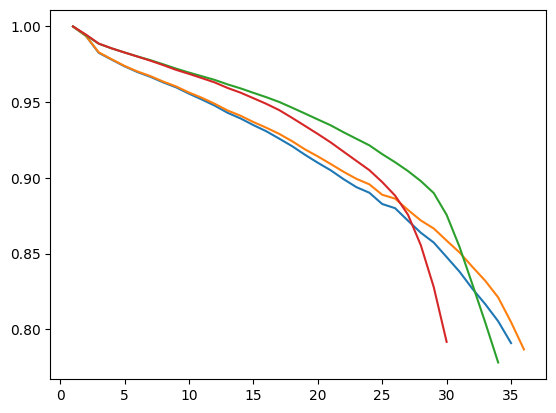

In [34]:
for xy in xy_pairs:
    plt.plot(xy[0], xy[1])